In [1]:
## Create a vector of the required packages for this analysis
req_packages <- c("AnnotationDbi", "AnnotationHub", "clusterProfiler", "ComplexHeatmap",
                  "edgeR", "ggplot2", "ggpubr", "gridExtra", "janitor", "patchwork",
                  "RColorBrewer", "RUVSeq", "splines", "stringr", "tidyverse", "viridis",
                  "vegan")

## load the packages, quietly
invisible(suppressWarnings(suppressMessages(
    lapply(req_packages, require, character.only = TRUE)
)))

### Set up data

In [2]:
## load in data
raw_reads <- read_tsv("stringtie_gene_counts.txt", skip = 1)

Rows: 16624 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (5): Geneid, Chr, Start, End, Strand
dbl (13): Length, /home/clavery/projects/pse_ag/workflow/HISAT-2/Dpse/DpseSR...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
## load in data
raw_reads <- read_tsv("stringtie_gene_counts.txt", skip = 1)

## clean up column names
names <- colnames(raw_reads) %>%
    as.data.frame() %>%
    rename(name = 1) %>%
    mutate(name = str_replace(name, "/home/clavery/projects/pse_ag/workflow/HISAT-2/Dpse/", ""),
           name = str_replace(name, "_Dpse.csorted.hisat2.bam", "")) %>%
    pull("name")
colnames(raw_reads) <- names

## just pull the count data
raw_counts <- raw_reads %>%
    column_to_rownames("Geneid") %>%
    select(contains("dpse") | contains("srm")) %>%
    select(contains("t"))

## filter for genes with more than 1 count per million in at least three columns
cpm_cm <- cpm(raw_counts)
thresh_cm <- cpm_cm > 5
keep_cm <- rowSums(thresh_cm) >= 3
reads <- raw_counts[keep_cm,]


head(reads)

,DpseSR_testes_1,DpseSR_testes_2,DpseSR_testes_3,Dpse_testes_1,Dpse_testes_2,Dpse_testes_3,SRM_testes_1,SRM_testes_2,SRM_testes_3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATP6,15841,13228,16826,18946,15259,34310,22722,27766,20384
COX3,43187,45074,42757,91623,73161,160092,85907,103893,69131
ND3,1602,1511,2047,1832,1898,6997,2561,3035,2244
ND5,931,1107,768,5490,3278,8385,6566,7093,4067
ND4,1550,1386,1327,5765,3857,8018,5854,6879,4162
ND6,184,144,249,370,307,1606,444,387,186


### Normalize reads

In [7]:
## create sample info data frame
sample_info <- colnames(reads) %>%
    as.data.frame() %>%
    rename(sample = 1) %>%
    separate(sample, into = c("species", "organ", "replicate"), remove = FALSE) %>%
    mutate(species = case_when(species == "Dpse" ~ "reference",
                               species == "DpseSR" ~ "sex ratio",
                               species == "SRM" ~ "mutant"),
          sample_name = paste(species, replicate, sep = "_"))

## create design matrix 
groups <- sample_info$species
design <- model.matrix(~0 + groups)
rownames(design) <- colnames(reads)
colnames(design) <- str_replace(colnames(design), "groups", "")

head(design)

,mutant,reference,sex ratio
DpseSR_testes_1,0,0,1
DpseSR_testes_2,0,0,1
DpseSR_testes_3,0,0,1
Dpse_testes_1,0,1,0
Dpse_testes_2,0,1,0
Dpse_testes_3,0,1,0


In [8]:
## create DGE object
set <- newSeqExpressionSet(as.matrix(reads), phenoData = data.frame(groups, row.names = colnames(reads)))
set <- betweenLaneNormalization(set, which="upper")

y <- DGEList(counts=counts(set), group=groups)
y <- calcNormFactors(y, method="upperquartile")
y <- estimateDisp(y, design, robust = T)
fit <- glmQLFit(y, design, dispersion = y$tagwise.dispersion, robust = T)
res <- residuals(fit, type="deviance")

## normalize with RUVr
batch_ruv_res <- RUVr(set, rownames(reads), k=3,res)

## create new design matrix with RUVr coefficients
design_2 <- model.matrix(~ 0 + groups, data = pData(batch_ruv_res))
colnames(design_2) <- gsub("groups", "", colnames(design_2))

## create DGElist object with new design
dgeList <- DGEList(counts = reads, group = groups)
dgeList <- calcNormFactors(dgeList)
dgeList <- estimateDisp(dgeList, design_2)
dgeList_fit <- glmQLFit(dgeList, design_2, robust = TRUE)
summary(dgeList$tagwise.dispersion)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.006254 0.009585 0.013130 0.016911 0.018922 1.682280 

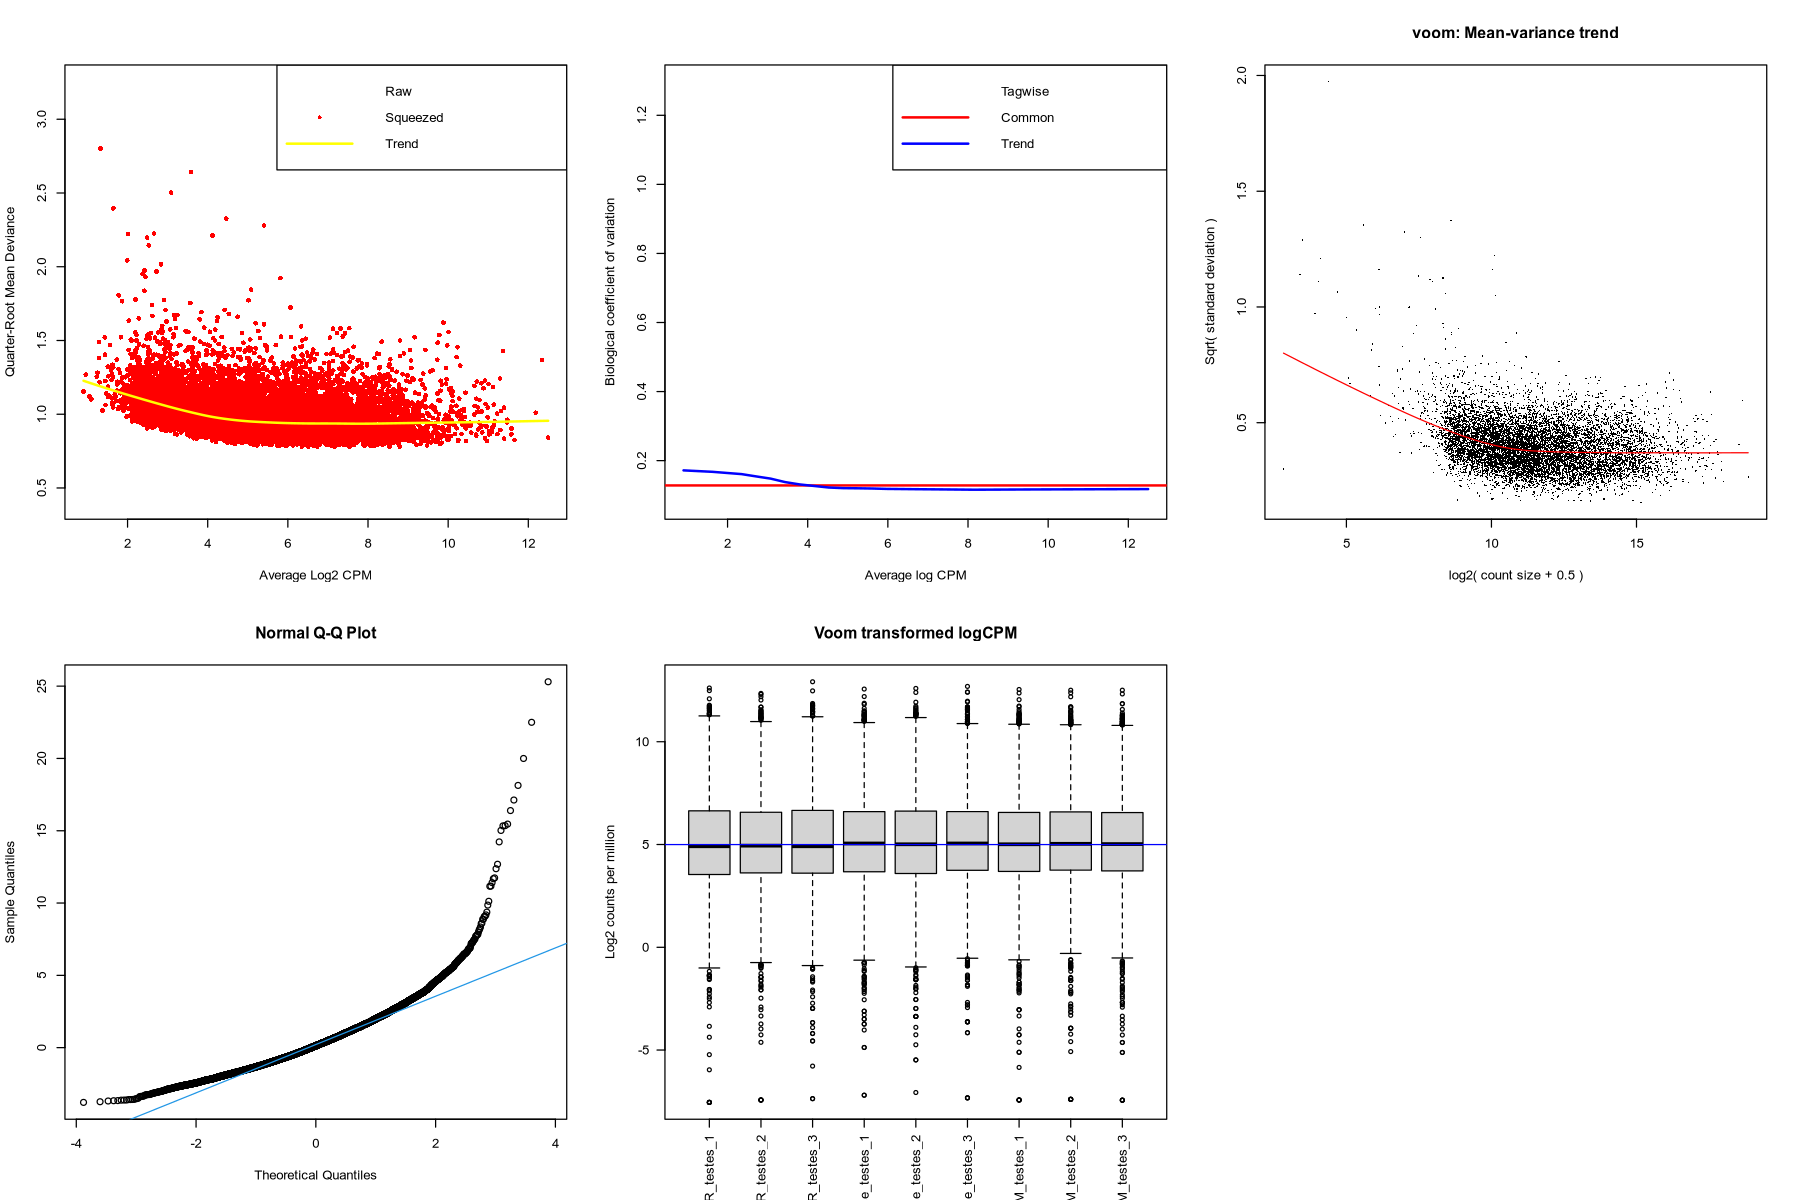

In [9]:
options(repr.plot.width = 15, repr.plot.height = 10)

# Use the function before each plot
par(mfrow = c(2, 3))

## QL dispersion plot
plotQLDisp(dgeList_fit, col.raw = "white", cex = 0.8, col.trend = "yellow", )

## Biological coefficient of variation
plotBCV(dgeList, col.tagwise = "white", cex = 0.8)

## Mean-variance trend
voom <- voom(dgeList, design_2, plot = TRUE)

## Goodness of fit/Q-Q plot
g.v <- gof(dgeList_fit, plot = FALSE, pcutoff = 0.05, adjust = "holm")
z.v <- zscoreGamma(g.v$gof.statistics,shape=g.v$df/2,scale=2)
qqnorm(z.v); qqline(z.v, col = 4,lwd=1,lty=1)

## normalized CPM check
boxplot(voom$E, xlab="", ylab="Log2 counts per million",las=2,main="Voom transformed logCPM")
abline(h=median(voom$E),col="blue")

In [10]:
## normalize with new design
y <- estimateDisp(y, design_2, robust = T)
fit <- glmQLFit(y, design_2, dispersion = y$tagwise.dispersion, robust = T)
res <- residuals(fit, type="deviance")

## normalize with RUVr
batch_ruv_res <- RUVr(set, rownames(reads), k=3,res)
RUVrNormalizedCounts <- normCounts(object = batch_ruv_res)
rownames(RUVrNormalizedCounts) <- rownames(reads)

## reformat normalized reads for saving
normalized_reads <- RUVrNormalizedCounts %>%
    as.data.frame() %>%
    rownames_to_column("gene")
head(normalized_reads)

,gene,DpseSR_testes_1,DpseSR_testes_2,DpseSR_testes_3,Dpse_testes_1,Dpse_testes_2,Dpse_testes_3,SRM_testes_1,SRM_testes_2,SRM_testes_3
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ATP6,14637,14098,13564,23222,24284,24514,23488,23238,22109
2,COX3,42238,41810,37607,103665,121462,118585,86822,88961,74696
3,ND3,1628,1621,1486,2936,3432,3402,2875,2560,2207
4,ND5,991,864,743,5170,6265,6466,6367,5827,4750
5,ND4,1469,1313,1180,5742,6461,6664,5733,5596,4898
6,ND6,186,176,159,525,676,725,495,267,226


### Determine LogFC

In [16]:
## create logfc for normalized_reads 

## create empty logfc table to add the future log fold change data to
logfc_norm <- data.frame(gene = normalized_reads$gene) %>%
    rownames_to_column("number")
pvalue_norm <- data.frame(gene = normalized_reads$gene) %>%
    rownames_to_column("number")

## get the list of unique organs and species
species <- unique(sample_info$species)

## run a loop of pairwise comparisons between each species pair for each organ
for (i in 1:(length(species) - 1)) {
    for (j in (i + 1):length(species)) {

## store the species names
species1 <- species[i]
species2 <- species[j]

## truncate all of the data based on the species
trunc_sample_info <- sample_info %>% 
    filter(species == species1 | species == species2)
trunc_cm <- normalized_reads %>%
    select(contains(trunc_sample_info[,1]))
trunc_groups <- trunc_sample_info$species
trunc_design <- model.matrix(~ trunc_groups)

## run differential gene expression
trunc_dgeList <- DGEList(counts = trunc_cm, group = trunc_groups)
trunc_dgeList <- calcNormFactors(trunc_dgeList)
trunc_dgeList <- estimateDisp(trunc_dgeList, trunc_design)
trunc_dgeList_fit <- glmQLFit(trunc_dgeList, trunc_design, robust = TRUE)

trunc_dge <- glmTreat(trunc_dgeList_fit, coef = 2)
trunc_dge_tags <- topTags(trunc_dge, n = NULL)
trunc_dge_logfc <- trunc_dge_tags$table$logFC

colname <- paste(species1, species2, sep = "_")

## add logfc to table 
df <- trunc_dge_tags$table %>%
    rownames_to_column("number") %>%
    select(c(number))
df[[colname]] <- trunc_dge_tags$table$logFC
logfc_norm <- logfc_norm %>%
    full_join(df, by = "number")

##add pvalue to table
df <- trunc_dge_tags$table %>%
    rownames_to_column("number") %>%
    select(c(number))
df[[colname]] <- trunc_dge_tags$table$PValue
pvalue_norm <- pvalue_norm %>%
    full_join(df, by = "number")
    }
}

Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”


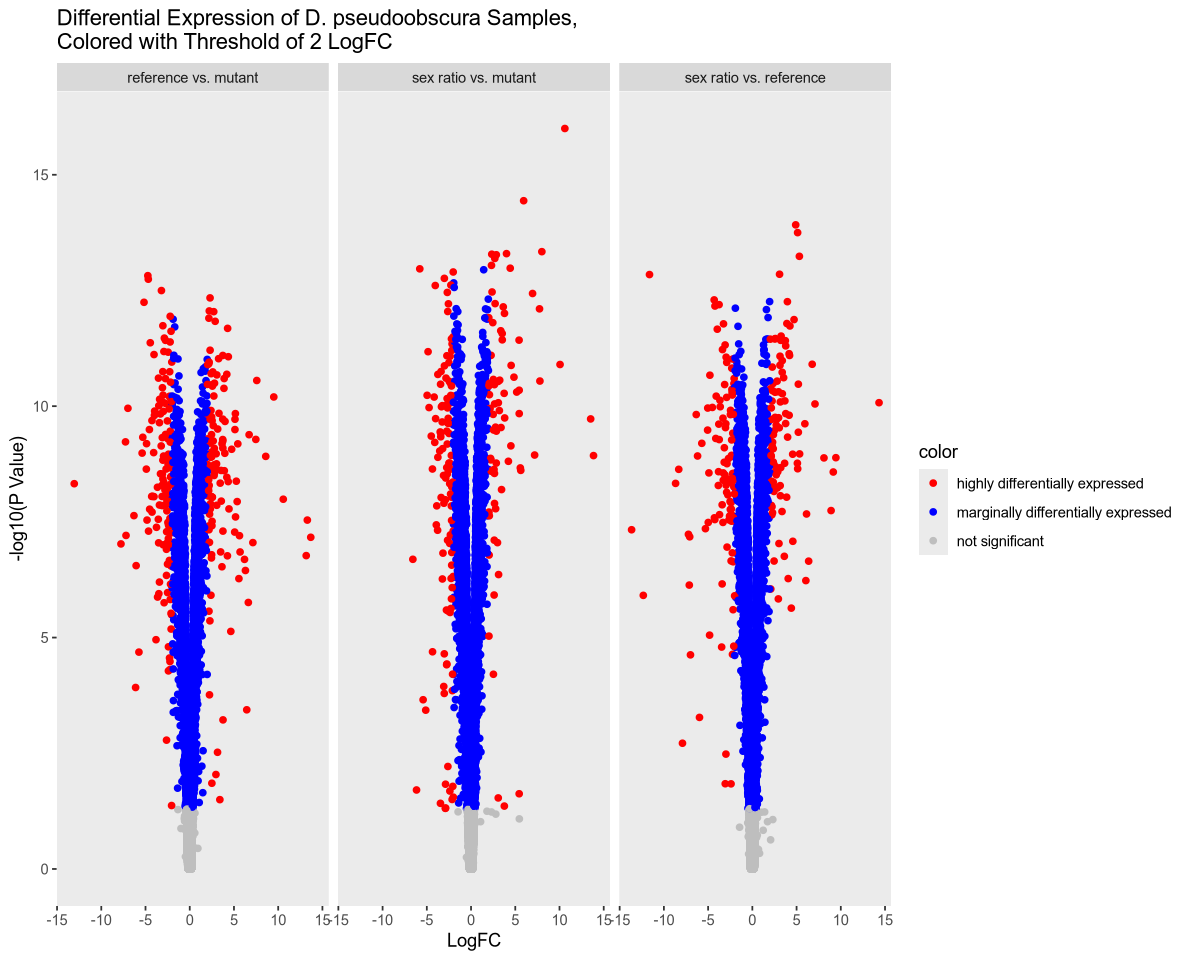

In [20]:
## transform the data into long format
logfc_long_norm <- logfc_norm %>%
    select(-number) %>%
    pivot_longer(!gene, names_to = "comparison", values_to = "logfc")
pvalue_long_norm <- pvalue_norm %>%
    select(-number) %>%
    pivot_longer(!gene, names_to = "comparison", values_to = "pvalue")

## join the values
comparison_norm <- logfc_long_norm %>%
    full_join(pvalue_long_norm, by = c("gene", "comparison")) %>%
    mutate(significance = case_when(pvalue < 0.05 ~ "significant",
                                    pvalue >= 0.05 ~ "not significant"),
           direction = case_when(logfc > 0 ~ "hyper",
                                 logfc < 0 ~ "hypo"),
           color = case_when(significance == "significant" & abs(logfc) > 2 ~ "highly differentially expressed",
                             significance == "significant" & abs(logfc) <= 2 ~ "marginally differentially expressed",
                             TRUE ~ "not significant"))

In [ ]:
write.csv(comparison_norm, "results/logfc_normalized.csv")